In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [2]:
df=pd.read_csv(r"C:\Users\laphouse\OneDrive\Desktop\data\data\train.csv")
test=pd.read_csv(r"C:\Users\laphouse\OneDrive\Desktop\data\data\test.csv")

In [3]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
df.drop(columns=['Unnamed: 0','id'], inplace=True)

ValueError: Cannot specify both 'axis' and 'index'/'columns'

In [ ]:
df.shape

(103904, 24)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  str    
 2   Customer Type                      103904 non-null  str    
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  str    
 5   Class                              103904 non-null  str    
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 non-null

In [ ]:
df.isnull().sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

0

### Data Visualization

In [ ]:
cat_col=df.select_dtypes(include='object')
num_col=df.select_dtypes(include='number')

C:\Users\laphouse\AppData\Local\Temp\ipykernel_468\1330807964.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=df.select_dtypes(include='object')


In [ ]:
cat_col

,Gender,Customer Type,Type of Travel,Class,satisfaction
0,Male,Loyal Customer,Personal Travel,Eco Plus,neutral or dissatisfied
1,Male,disloyal Customer,Business travel,Business,neutral or dissatisfied
2,Female,Loyal Customer,Business travel,Business,satisfied
3,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
4,Male,Loyal Customer,Business travel,Business,satisfied
...,...,...,...,...,...
103899,Female,disloyal Customer,Business travel,Eco,neutral or dissatisfied
103900,Male,Loyal Customer,Business travel,Business,satisfied
103901,Male,disloyal Customer,Business travel,Business,neutral or dissatisfied
103902,Female,disloyal Customer,Business travel,Eco,neutral or dissatisfied


In [ ]:
df['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    58697
satisfied                  44897
Name: count, dtype: int64

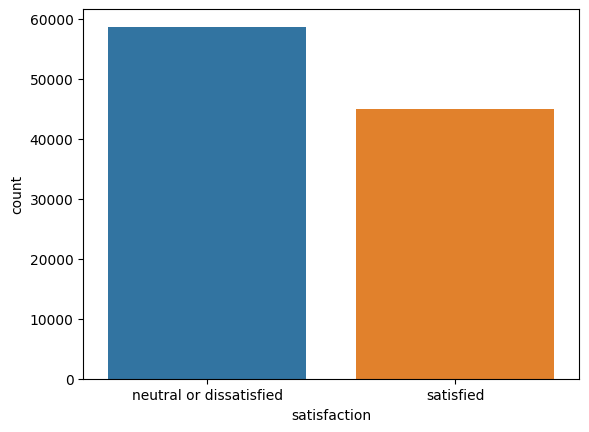

In [ ]:
sns.countplot(data=df,x=df['satisfaction'],hue='satisfaction')
plt.show()

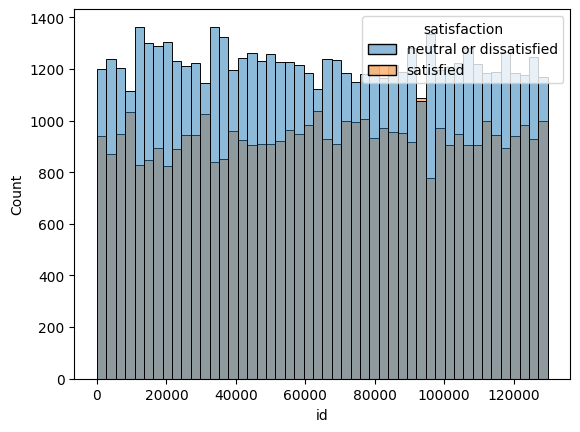

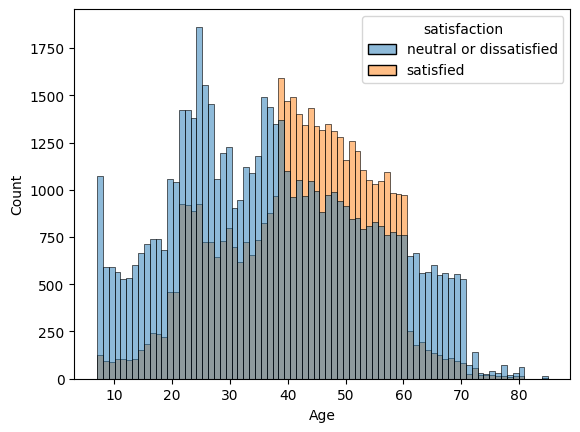

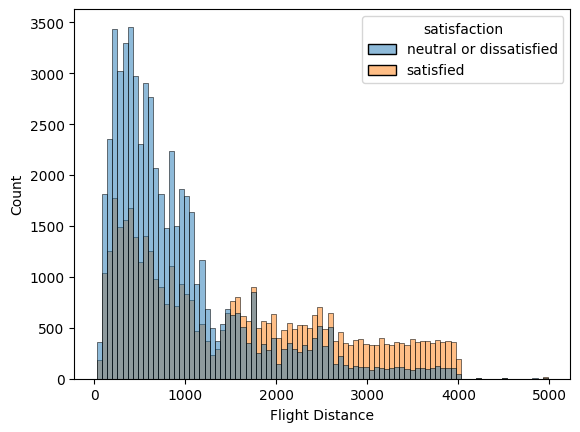

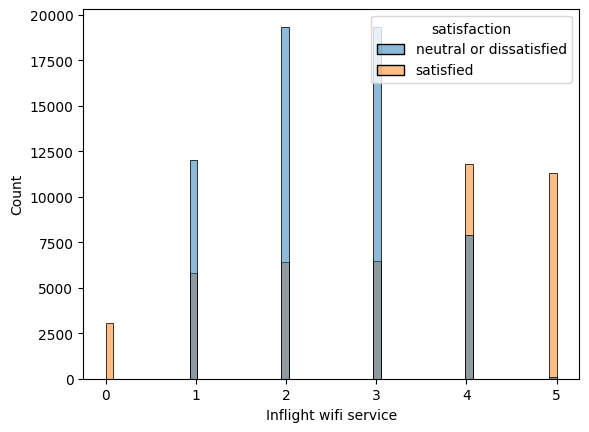

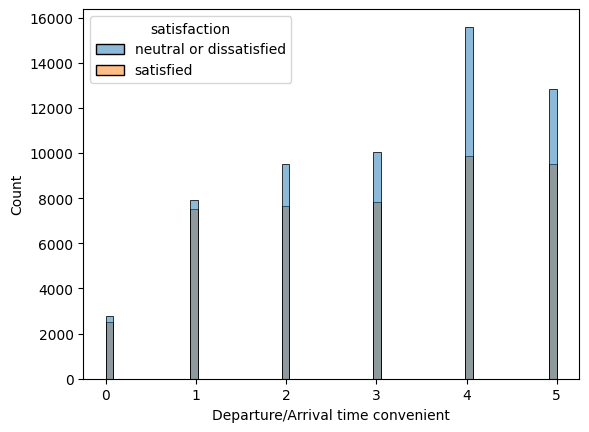

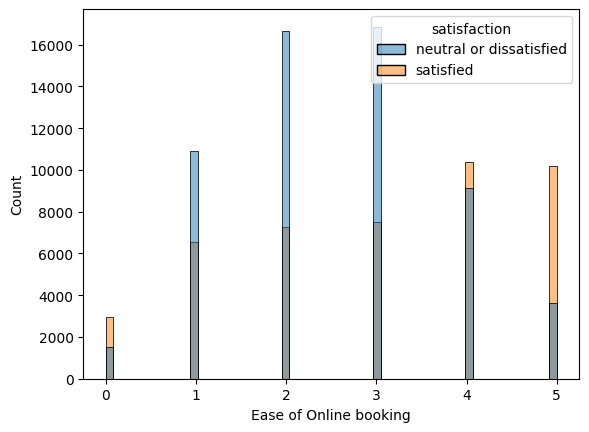

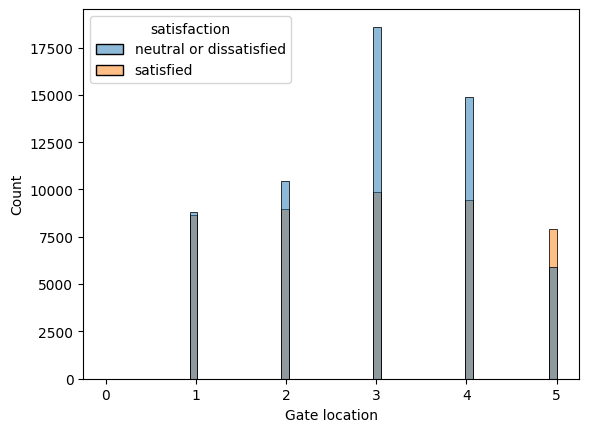

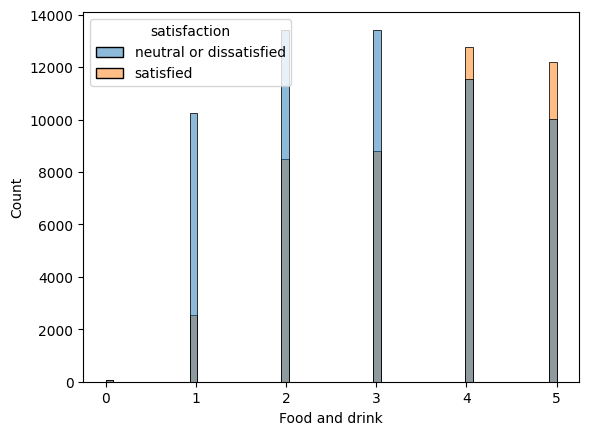

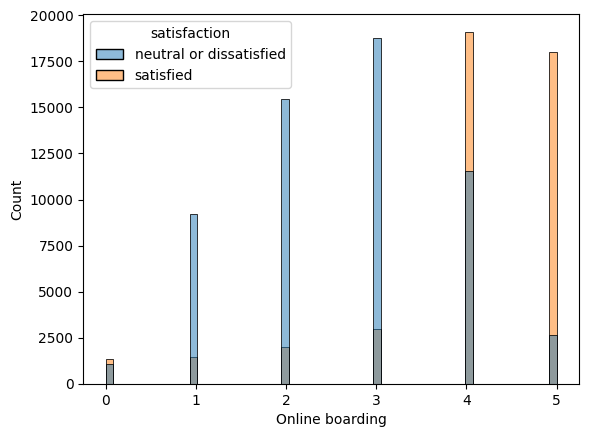

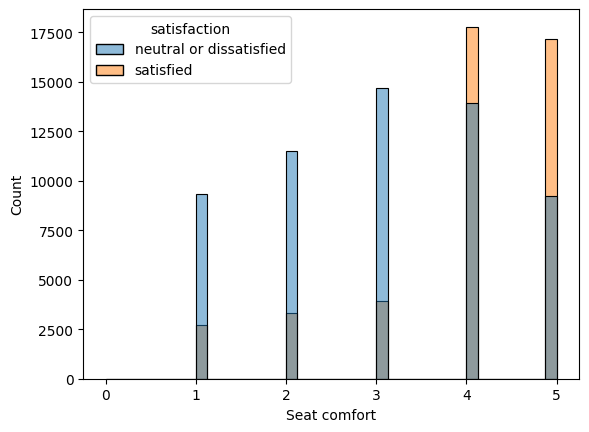

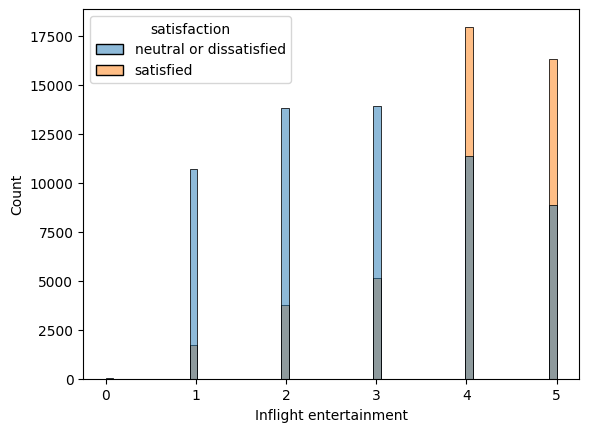

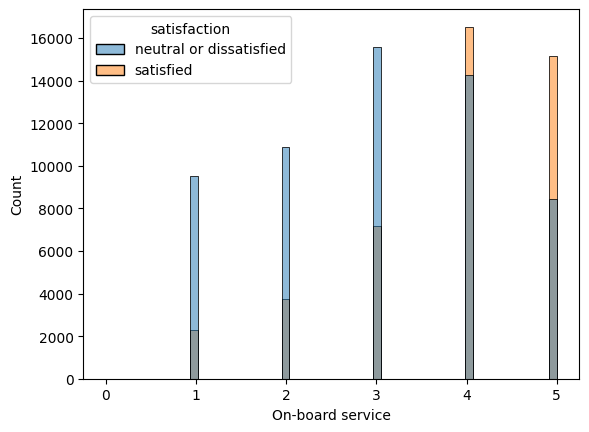

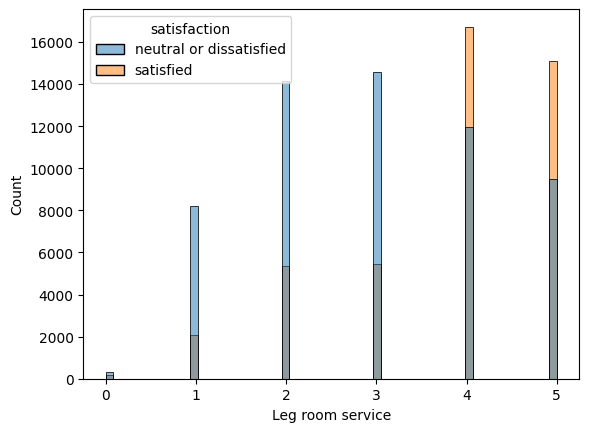

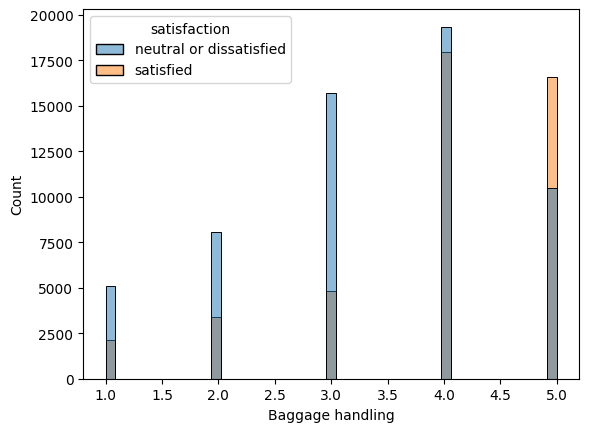

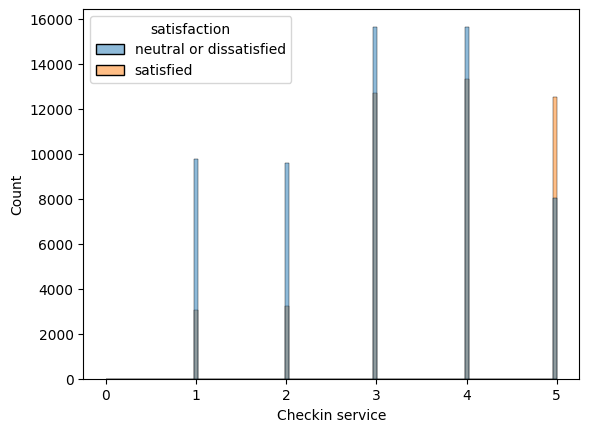

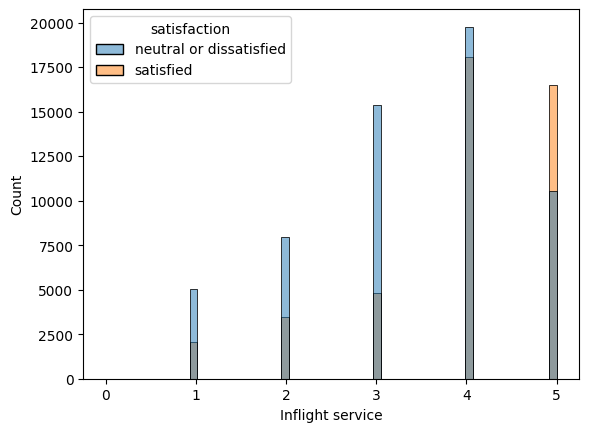

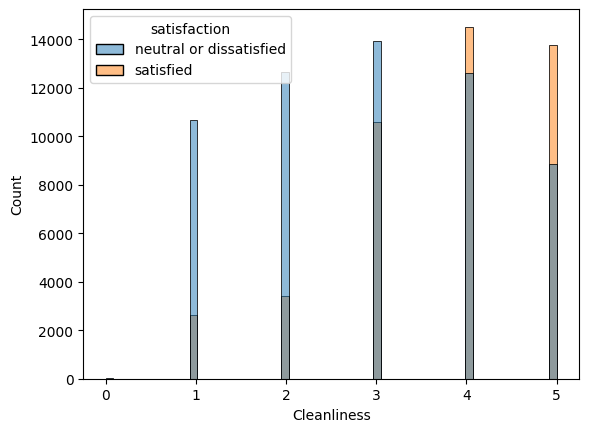

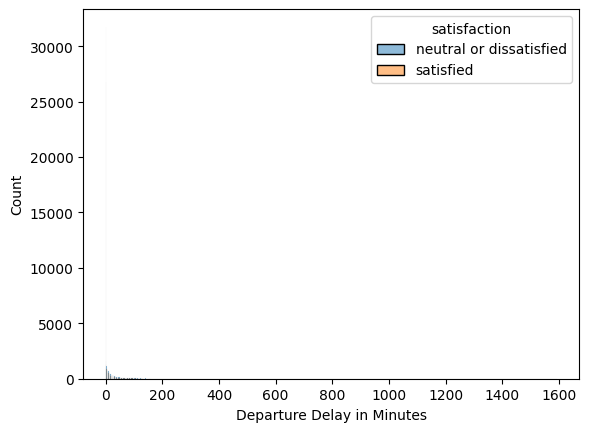

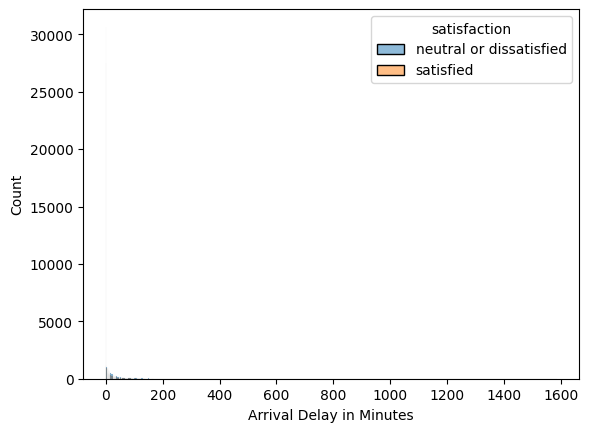

In [ ]:
for col in num_col :
    sns.histplot(data=df,x=col,hue='satisfaction')
    plt.show()

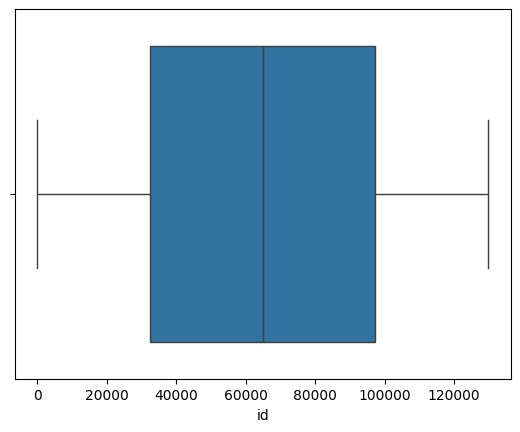

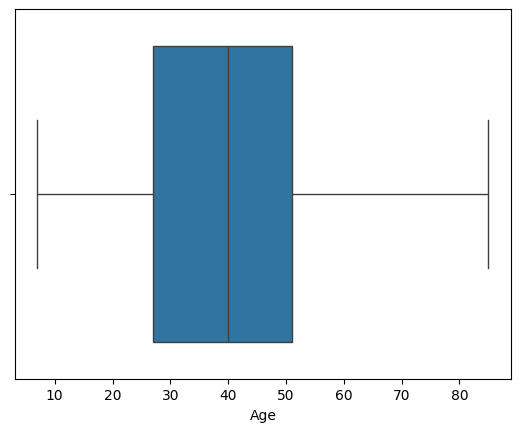

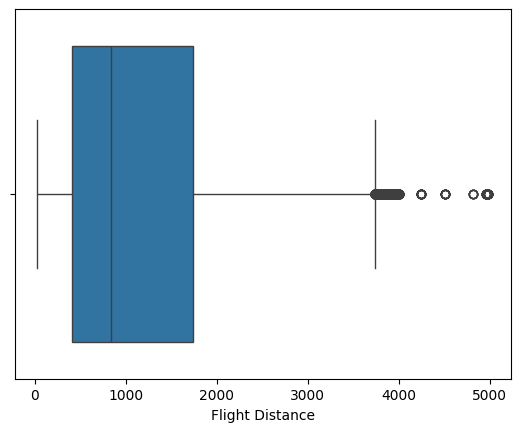

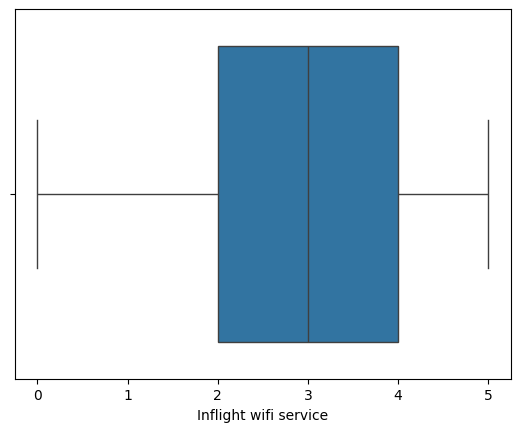

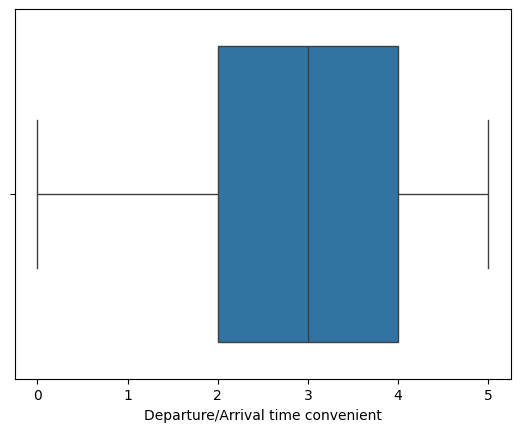

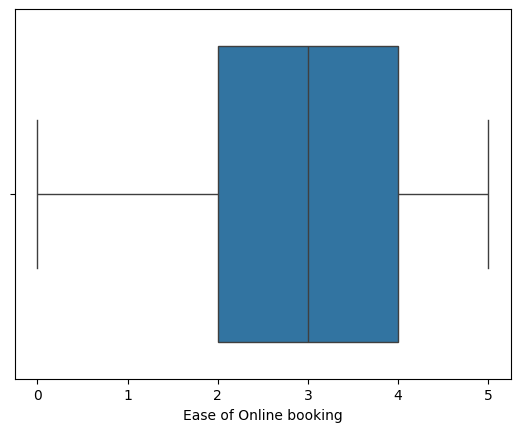

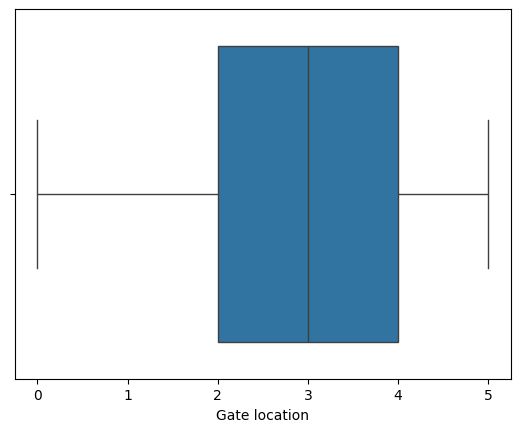

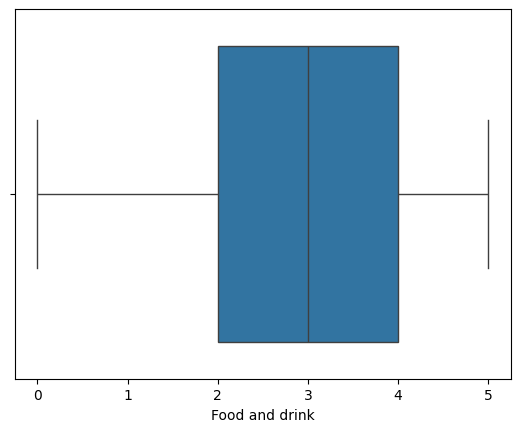

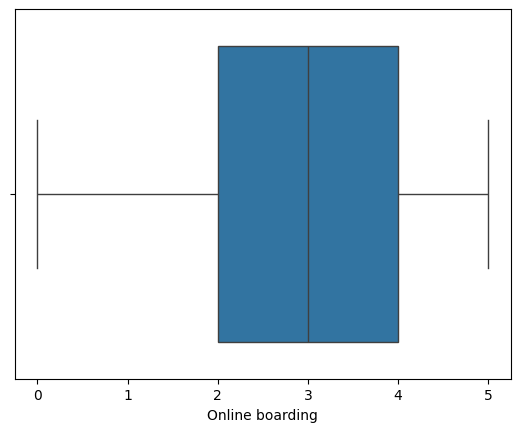

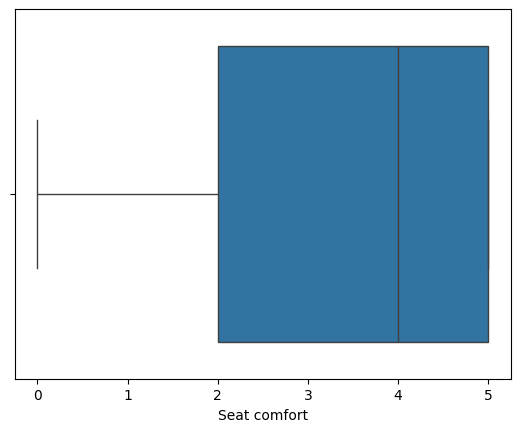

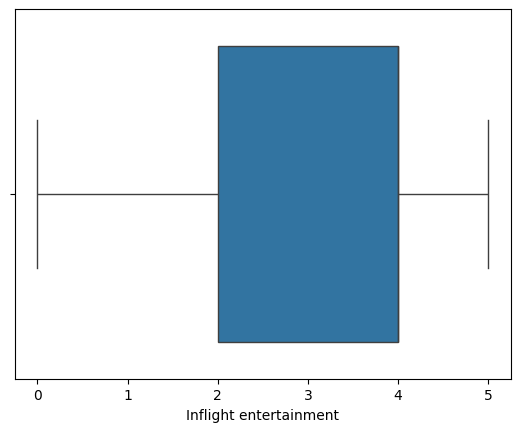

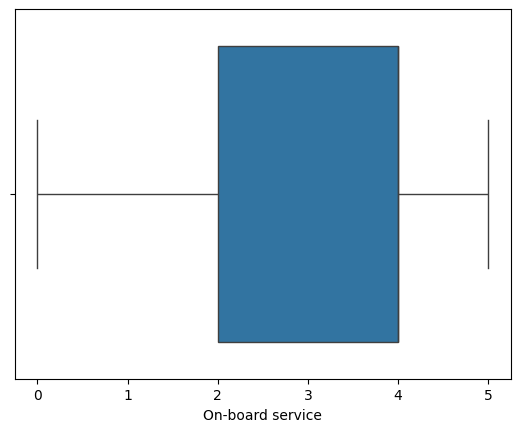

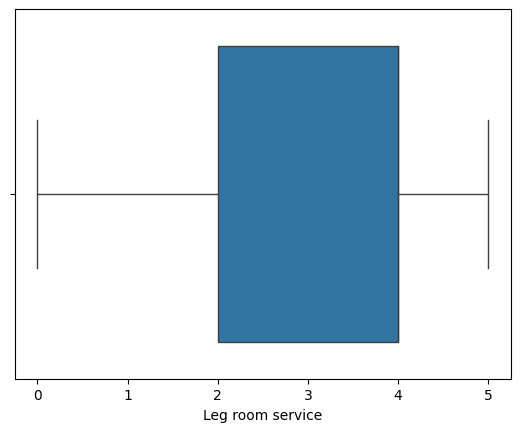

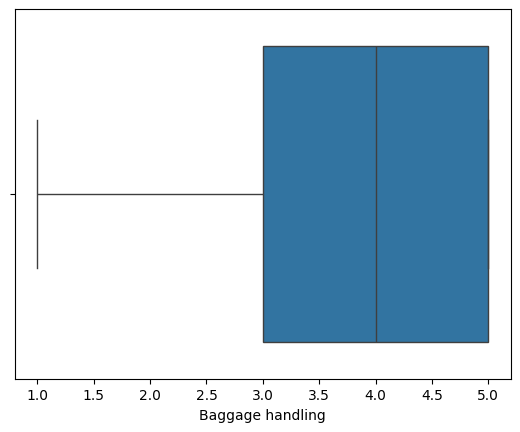

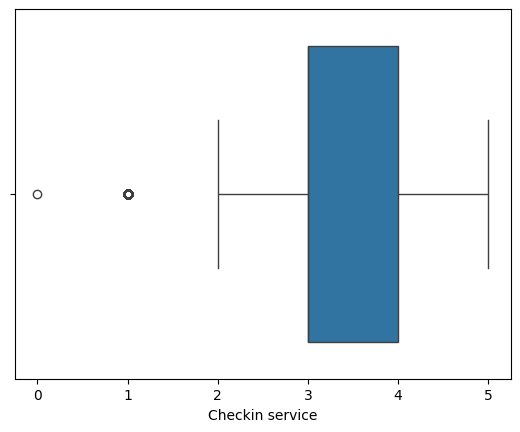

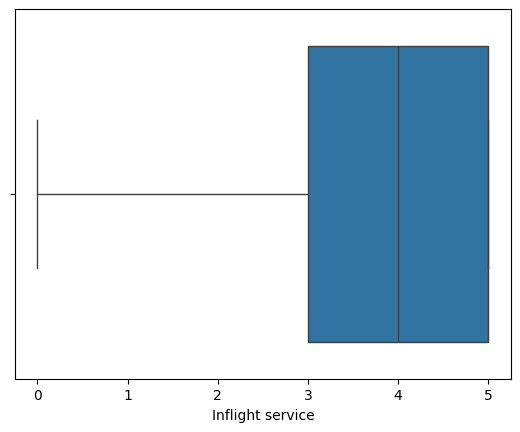

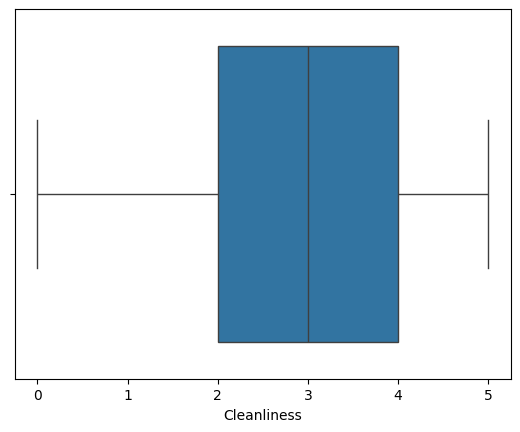

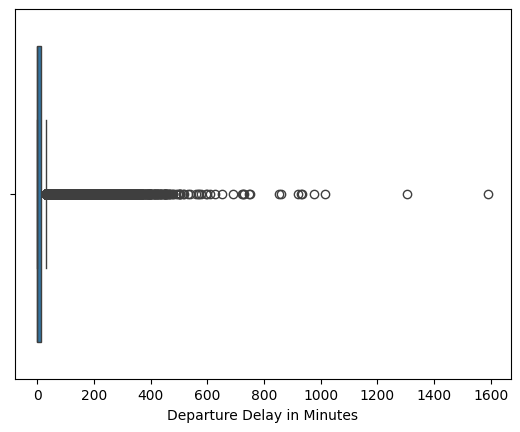

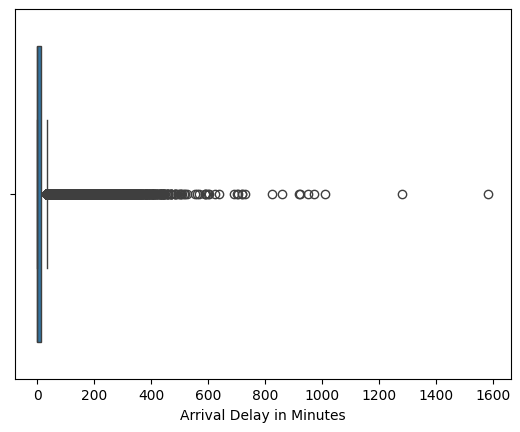

In [ ]:
for col in num_col :
    sns.boxplot(data=df,x=col)
    plt.show()

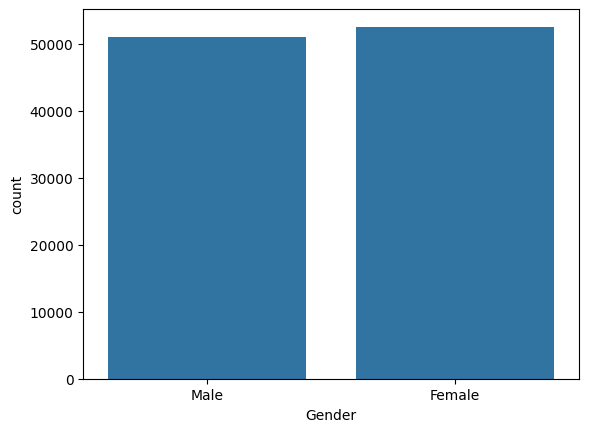

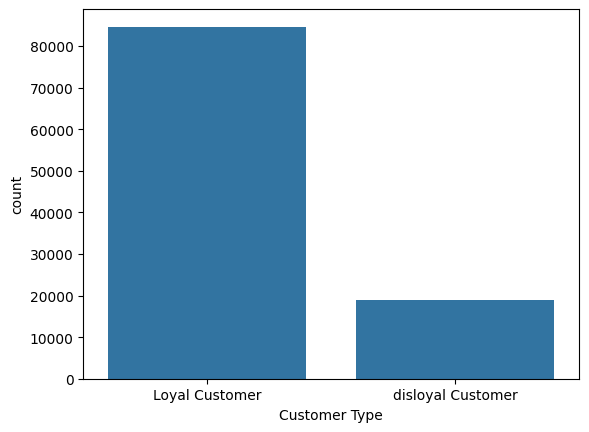

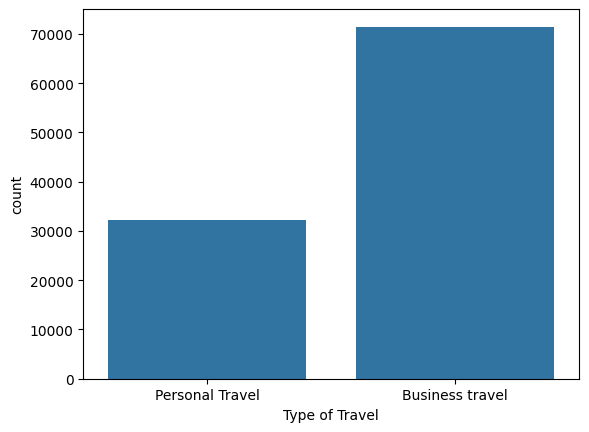

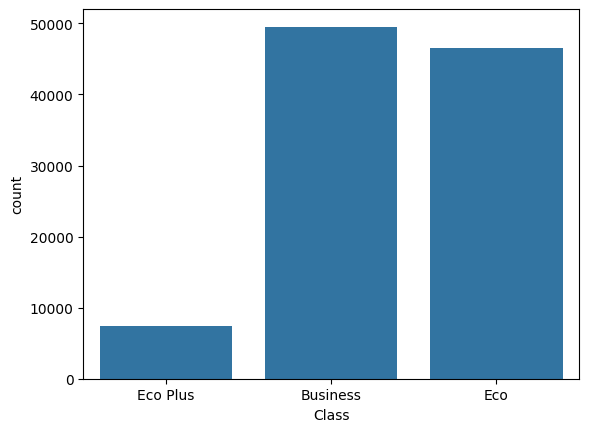

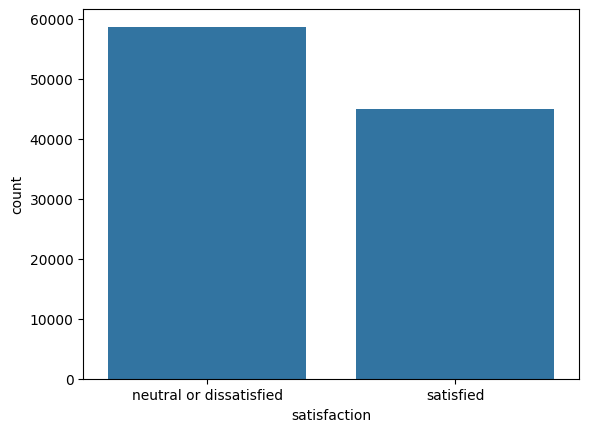

In [ ]:
for col in cat_col :
    sns.countplot(data=df,x=col)
    plt.show()

### Data Preprocessing

In [ ]:
le=LabelEncoder()
for col in cat_col:
    df[col]=le.fit_transform(df[col])
    

In [ ]:
scaler=StandardScaler()
for col in num_col:
    df[col]=scaler.fit_transform(df[[col]])

In [ ]:
df

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0.139602,1,0,-1.745542,1,2,-0.731305,0.203521,0.616249,0.173716,...,1.231530,0.479237,-0.267143,0.311853,0.549773,1.156211,1.305913,0.268966,0.072905,0
1,-1.598890,1,1,-0.951526,0,0,-0.956916,0.203521,-0.695032,0.173716,...,-1.769166,-1.849452,1.253304,-0.534854,-1.821038,0.305580,-1.742432,-0.360682,-0.237184,0
2,1.203545,0,0,-0.885358,0,0,-0.047454,-0.549571,-0.695032,-0.541118,...,1.231530,0.479237,-0.267143,0.311853,0.549773,0.305580,1.305913,-0.386917,-0.392229,1
3,-1.092251,0,0,-0.951526,0,0,-0.629028,-0.549571,1.271890,1.603383,...,-1.018992,-1.073222,1.253304,-0.534854,-1.821038,0.305580,-0.980345,-0.098328,-0.159662,0
4,1.451032,1,0,1.430521,0,0,-0.977973,0.203521,-0.039391,0.173716,...,-0.268818,-0.296993,0.493081,0.311853,-0.240497,-0.545051,-0.218259,-0.386917,-0.392229,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,0.780248,0,1,-1.083862,0,1,-1.000033,-0.549571,-1.350673,-0.541118,...,-1.018992,-0.296993,-1.787590,0.311853,-1.030767,-0.545051,-0.980345,-0.308211,-0.392229,0
103900,0.217684,1,0,0.636505,0,0,1.160818,0.956612,0.616249,0.888550,...,1.231530,1.255467,1.253304,1.158561,1.340043,1.156211,0.543827,-0.386917,-0.392229,1
103901,0.103644,1,1,-0.620686,0,0,0.807862,-1.302662,-1.350673,-1.255951,...,0.481356,-0.296993,-1.027367,0.311853,1.340043,1.156211,0.543827,-0.203270,-0.030458,0
103902,-0.287487,0,1,-1.150030,0,1,-0.189839,-1.302662,-1.350673,-1.255951,...,-1.769166,0.479237,1.253304,-2.228269,1.340043,0.305580,-1.742432,-0.386917,-0.392229,0
